# <span style='color:Red'>Misbinding models (Part 2)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, pandas, re, ast, seaborn, jlib, sklearn, pickle
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/models/'
imageFormats = ['svg','pdf']
exportsPathBase = 'exports/'
exportsPath = 'exports/biasModels/'
exportsPathTemp = 'exports/biasModels/temp/full/'

desiredEffectSize = 'ges'

significanceSize = 14

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}
paletteInformative = {'Chunkable':'#7ca3cc','Non-chunkable':'#d68e5d'}
paletteUninformative = {'Chunkable':'#c7f0ff','Non-chunkable':'#ffdba8'}
paletteIUCombined = {'Chunkable\nInformative':"#7ca3cc",'Non-chunkable\nInformative':"#d68e5d",
                     'Chunkable\nUninformative':"#c7f0ff",'Non-chunkable\nUninformative':"#ffdba8"}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

if not os.path.exists(exportsPath):
    os.makedirs(exportsPath)

if not os.path.exists(exportsPathTemp):
    os.makedirs(exportsPathTemp)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPathBase+"exp4Values.csv")

modelComparisonData = pandas.read_csv(exportsPath+'modelsTrainBIC_SPMBSM_df.csv')

allParticipantData = pandas.read_csv(exportsPathBase+'participantData_long.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path','Target'],axis=1,inplace=True)

## <span style='color:Red'>Fit all trials together</span>

In [2]:
if not os.path.exists(exportsPathTemp+'allFits.pkl'):
    allFits,allBIC = jlib.analysis.models.fitAllBiasModelsCV(allParticipantData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFits.pkl','wb') as fp:
        pickle.dump(allFits,fp)
    with open(exportsPathTemp+'allBIC.pkl','wb') as fp:
        pickle.dump(allBIC,fp)
else:
    with open(exportsPathTemp+'allFits.pkl','rb') as fp:
        allFits = pickle.load(fp)
    with open(exportsPathTemp+'allBIC.pkl','rb') as fp:
        allBIC = pickle.load(fp)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    7.3s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:   16.5s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   27.4s
[Parallel(n_jobs=5)]: Done  18 out of  24 | elapsed:   32.1s remaining:   10.6s
[Parallel(n_jobs=5)]: Done  21 out of  24 | elapsed:   37.5s remaining:    5.3s
[Parallel(n_jobs=5)]: Done  24 out of  24 | elapsed:   41.4s finished


In [3]:
finalBICTrain = {'MBSK_all':[],'MBDK_all':[],'NMB_all':[],'Bias_all':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allBIC['MBSK'][participant])
    b = numpy.array(allBIC['MBDK'][participant])
    c = numpy.array(allBIC['NMB'][participant])
    d = numpy.array(allBIC['Bias'][participant])

    finalBICTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])

numpy.sum(finalBICTrain['MBSK_all']),numpy.sum(finalBICTrain['MBDK_all']),numpy.sum(finalBICTrain['NMB_all']),numpy.sum(finalBICTrain['Bias_all'])

(27127.108822569724, 27034.80157971495, 26980.596442727645, 25959.305732774257)

## <span style='color:Red'>Fit chunking vs non-chunking trials</span>

In [4]:
chunkingData = allParticipantData.copy()
chunkingData.drop(chunkingData[chunkingData['Trial type']=='Non-chunkable'].index,axis=0,inplace=True)
nonChunkingData = allParticipantData.copy()
nonChunkingData.drop(nonChunkingData[nonChunkingData['Trial type']=='Chunkable'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunking.pkl'):
    allFitsChunking,allBICChunking = jlib.analysis.models.fitAllBiasModelsCV(chunkingData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsChunking.pkl','wb') as fp:
        pickle.dump(allFitsChunking,fp)
    with open(exportsPathTemp+'allBICChunking.pkl','wb') as fp:
        pickle.dump(allBICChunking,fp)

    allFitsNonChunking,allBICNonChunking = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','wb') as fp:
        pickle.dump(allFitsNonChunking,fp)
    with open(exportsPathTemp+'allBICNonChunking.pkl','wb') as fp:
        pickle.dump(allBICNonChunking,fp)
else:
    with open(exportsPathTemp+'allFitsChunking.pkl','rb') as fp:
        allFitsChunking = pickle.load(fp)
    with open(exportsPathTemp+'allBICChunking.pkl','rb') as fp:
        allBICChunking = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','rb') as fp:
        allFitsNonChunking = pickle.load(fp)
    with open(exportsPathTemp+'allBICNonChunking.pkl','rb') as fp:
        allBICNonChunking = pickle.load(fp)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    7.1s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:   15.0s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   20.9s
[Parallel(n_jobs=5)]: Done  18 out of  24 | elapsed:   24.8s remaining:    8.2s
[Parallel(n_jobs=5)]: Done  21 out of  24 | elapsed:   27.1s remaining:    3.8s
[Parallel(n_jobs=5)]: Done  24 out of  24 | elapsed:   30.5s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    5.5s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    9.1s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   15.5s
[Parallel(n_jobs=5)]: Done  18 out of  24 | elapsed:   19.0s remaining:    6.3s
[Parallel(n_jobs=5)]: Done  21 out of  24 | elapsed:   21.0s remaining:    2.9s
[Parallel(n_jobs=5)]: Done  24 out of  24 | elapsed:   23.1s finished


In [5]:
propsToAdd = ['MBSK_C_all','MBDK_C_all','NMB_C_all','Bias_C_all',
              'MBSK_NC_all','MBDK_NC_all','NMB_NC_all','Bias_NC_all']
for prop in propsToAdd:
    finalBICTrain[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allBICChunking['MBSK'][participant])
    b = numpy.array(allBICChunking['MBDK'][participant])
    c = numpy.array(allBICChunking['NMB'][participant])
    d = numpy.array(allBICChunking['Bias'][participant])

    finalBICTrain['MBSK_C_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_C_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_C_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_C_all'].append(numpy.sum(d,axis=0)[0])

    a = numpy.array(allBICNonChunking['MBSK'][participant])
    b = numpy.array(allBICNonChunking['MBDK'][participant])
    c = numpy.array(allBICNonChunking['NMB'][participant])
    d = numpy.array(allBICNonChunking['Bias'][participant])

    finalBICTrain['MBSK_NC_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_NC_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_NC_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_NC_all'].append(numpy.sum(d,axis=0)[0])

[numpy.sum(finalBICTrain['MBSK_C_all']),numpy.sum(finalBICTrain['MBDK_C_all']),
 numpy.sum(finalBICTrain['NMB_C_all']),numpy.sum(finalBICTrain['Bias_C_all'])]

[16455.543430181748, 16443.369742198738, 16315.15396200083, 15269.652681497984]

In [6]:
[numpy.sum(finalBICTrain['MBSK_NC_all']),numpy.sum(finalBICTrain['MBDK_NC_all']),
 numpy.sum(finalBICTrain['NMB_NC_all']),numpy.sum(finalBICTrain['Bias_NC_all'])]

[10462.06431026107, 10472.797515821308, 10350.30675904917, 10340.478904588243]

## <span style='color:Red'>Fit chunking vs non-chunking = f(cue)</span>

In [7]:
chunkingIData = chunkingData.copy()
chunkingIData.drop(chunkingIData[chunkingIData['Cue type']=='Uninformative'].index,axis=0,inplace=True)
chunkingUData = chunkingData.copy()
chunkingUData.drop(chunkingUData[chunkingUData['Cue type']=='Informative'].index,axis=0,inplace=True)

nonChunkingIData = nonChunkingData.copy()
nonChunkingIData.drop(nonChunkingIData[nonChunkingIData['Cue type']=='Uninformative'].index,axis=0,inplace=True)
nonChunkingUData = nonChunkingData.copy()
nonChunkingUData.drop(nonChunkingUData[nonChunkingUData['Cue type']=='Informative'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunkingI.pkl'):
    allFitsChunkingI,allBICChunkingI = jlib.analysis.models.fitAllBiasModelsCV(chunkingIData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsChunkingI.pkl','wb') as fp:
        pickle.dump(allFitsChunkingI,fp)
    with open(exportsPathTemp+'allBICChunkingI.pkl','wb') as fp:
        pickle.dump(allBICChunkingI,fp)

    allFitsChunkingU,allBICChunkingU = jlib.analysis.models.fitAllBiasModelsCV(chunkingUData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsChunkingU.pkl','wb') as fp:
        pickle.dump(allFitsChunkingU,fp)
    with open(exportsPathTemp+'allBICChunkingU.pkl','wb') as fp:
        pickle.dump(allBICChunkingU,fp)

    allFitsNonChunkingI,allBICNonChunkingI = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingIData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunkingI.pkl','wb') as fp:
        pickle.dump(allFitsNonChunkingI,fp)
    with open(exportsPathTemp+'allBICNonChunkingI.pkl','wb') as fp:
        pickle.dump(allBICNonChunkingI,fp)

    allFitsNonChunkingU,allBICNonChunkingU = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingUData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunkingU.pkl','wb') as fp:
        pickle.dump(allFitsNonChunkingU,fp)
    with open(exportsPathTemp+'allBICNonChunkingU.pkl','wb') as fp:
        pickle.dump(allBICNonChunkingU,fp)
else:
    with open(exportsPathTemp+'allFitsChunkingI.pkl','rb') as fp:
        allFitsChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allBICChunkingI.pkl','rb') as fp:
        allBICChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allFitsChunkingU.pkl','rb') as fp:
        allFitsChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allBICChunkingU.pkl','rb') as fp:
        allBICChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunkingI.pkl','rb') as fp:
        allFitsNonChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allBICNonChunkingI.pkl','rb') as fp:
        allBICNonChunkingI = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunkingU.pkl','rb') as fp:
        allFitsNonChunkingU = pickle.load(fp)
    with open(exportsPathTemp+'allBICNonChunkingU.pkl','rb') as fp:
        allBICNonChunkingU = pickle.load(fp)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    3.2s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    6.9s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   13.5s
[Parallel(n_jobs=5)]: Done  18 out of  24 | elapsed:   14.5s remaining:    4.8s
[Parallel(n_jobs=5)]: Done  21 out of  24 | elapsed:   17.7s remaining:    2.4s
[Parallel(n_jobs=5)]: Done  24 out of  24 | elapsed:   19.5s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    5.2s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    8.7s
[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:   15.8s
[Parallel(n_jobs=5)]: Done  18 out of  24 | elapsed:   17.2s remaining:    5.7s
[Parallel(n_jobs=5)]: Done  21 out of  24 | elapsed:   18.8s remaining:    2.6s
[Parallel(n_jobs=5)]: Done  24 out of  24 | elapsed:   23.1s finished
[Parallel(n_jobs=5)]: Us

In [8]:
propsToAdd = ['MBSK_C_I','MBDK_C_I','NMB_C_I','Bias_C_I',
              'MBSK_C_U','MBDK_C_U','NMB_C_U','Bias_C_U',
              'MBSK_NC_I','MBDK_NC_I','NMB_NC_I','Bias_NC_I',
              'MBSK_NC_U','MBDK_NC_U','NMB_NC_U','Bias_NC_U']
for prop in propsToAdd:
    finalBICTrain[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allBICChunkingI['MBSK'][participant])
    b = numpy.array(allBICChunkingI['MBDK'][participant])
    c = numpy.array(allBICChunkingI['NMB'][participant])
    d = numpy.array(allBICChunkingI['Bias'][participant])

    finalBICTrain['MBSK_C_I'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_C_I'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_C_I'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_C_I'].append(numpy.sum(d,axis=0)[0])

    a = numpy.array(allBICChunkingU['MBSK'][participant])
    b = numpy.array(allBICChunkingU['MBDK'][participant])
    c = numpy.array(allBICChunkingU['NMB'][participant])
    d = numpy.array(allBICChunkingU['Bias'][participant])

    finalBICTrain['MBSK_C_U'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_C_U'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_C_U'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_C_U'].append(numpy.sum(d,axis=0)[0])

    a = numpy.array(allBICNonChunkingI['MBSK'][participant])
    b = numpy.array(allBICNonChunkingI['MBDK'][participant])
    c = numpy.array(allBICNonChunkingI['NMB'][participant])
    d = numpy.array(allBICNonChunkingI['Bias'][participant])

    finalBICTrain['MBSK_NC_I'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_NC_I'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_NC_I'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_NC_I'].append(numpy.sum(d,axis=0)[0])

    a = numpy.array(allBICNonChunkingU['MBSK'][participant])
    b = numpy.array(allBICNonChunkingU['MBDK'][participant])
    c = numpy.array(allBICNonChunkingU['NMB'][participant])
    d = numpy.array(allBICNonChunkingU['Bias'][participant])

    finalBICTrain['MBSK_NC_U'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_NC_U'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_NC_U'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_NC_U'].append(numpy.sum(d,axis=0)[0])

[numpy.sum(finalBICTrain['MBSK_C_I']),numpy.sum(finalBICTrain['MBDK_C_I']),
 numpy.sum(finalBICTrain['NMB_C_I']),numpy.sum(finalBICTrain['Bias_C_I'])]

[7376.16982116788, 7426.533144036956, 7253.1065870053535, 6785.891741226555]

In [9]:
[numpy.sum(finalBICTrain['MBSK_C_U']),numpy.sum(finalBICTrain['MBDK_C_U']),
 numpy.sum(finalBICTrain['NMB_C_U']),numpy.sum(finalBICTrain['Bias_C_U'])]

[9190.63508463245, 9220.546154704183, 9066.455966135682, 8552.057799220314]

In [10]:
[numpy.sum(finalBICTrain['MBSK_NC_I']),numpy.sum(finalBICTrain['MBDK_NC_I']),
 numpy.sum(finalBICTrain['NMB_NC_I']),numpy.sum(finalBICTrain['Bias_NC_I'])]

[4950.358166794039, 4959.869761851328, 4850.612308550208, 4888.072110334044]

In [11]:
[numpy.sum(finalBICTrain['MBSK_NC_U']),numpy.sum(finalBICTrain['MBDK_NC_U']),
 numpy.sum(finalBICTrain['NMB_NC_U']),numpy.sum(finalBICTrain['Bias_NC_U'])]

[5656.58635991824, 5726.98934934013, 5561.13733138556, 5575.517546868377]

In [12]:
finalBICTrain['Subject'] = numpy.unique(allParticipantData['Subject'])
finalBICTrainDF = pandas.DataFrame.from_dict(finalBICTrain)

for col in finalBICTrainDF.columns:
    finalBICTrainDF[col] = finalBICTrainDF[col].apply(lambda x: x[0] if isinstance(x, (list, numpy.ndarray)) else x)

finalBICTrainDF.to_csv(exportsPath+"modelsTrainBIC.csv")

In [13]:
finalBICTrainDF

,MBSK_all,MBDK_all,NMB_all,Bias_all,MBSK_C_all,MBDK_C_all,NMB_C_all,Bias_C_all,MBSK_NC_all,MBDK_NC_all,...,Bias_C_U,MBSK_NC_I,MBDK_NC_I,NMB_NC_I,Bias_NC_I,MBSK_NC_U,MBDK_NC_U,NMB_NC_U,Bias_NC_U,Subject
0,1140.833438,1145.141285,1134.545130,1025.162968,587.734594,591.676188,581.850752,470.990498,528.477371,533.199296,...,280.963081,256.671230,259.480769,252.164175,251.953893,279.349793,283.838519,274.859239,273.646907,400
1,878.103032,869.051747,871.847742,804.252253,450.960595,445.155446,445.073315,388.426242,406.728458,409.586877,...,257.807870,215.080232,215.994481,210.713496,205.821068,201.045803,205.269274,196.660069,199.660501,401
2,1309.411975,1272.574278,1303.141814,1306.766744,875.928131,852.294680,870.028880,873.802022,444.672782,436.273542,...,538.742944,204.938363,203.535518,200.538149,196.059005,241.961146,241.925706,238.808053,241.994672,403
3,1387.812802,1393.085809,1381.571203,1372.853479,936.546157,941.584911,930.677632,918.266636,464.056071,468.596336,...,448.647535,237.881024,241.908743,236.372318,237.804922,233.306959,237.558320,228.924241,226.615175,404
4,886.546249,888.288496,880.292910,865.070286,529.135845,528.009739,523.250374,504.994945,355.056811,360.130443,...,282.057483,141.120169,143.188013,136.736596,140.736681,219.248837,223.386993,214.864404,218.600976,405
5,1277.928901,1271.784024,1271.837794,1277.828273,862.481508,854.006963,856.592967,861.584236,425.285343,430.135516,...,485.429856,210.565345,214.339071,206.209884,210.551350,223.529307,225.285103,219.455930,222.957685,406
6,1444.934380,1450.034476,1438.720231,1436.050890,952.229106,956.447200,946.340321,947.663670,498.722416,503.789788,...,522.256327,252.096984,256.427074,247.712169,250.312637,257.398457,261.238450,253.025815,250.157101,407
7,1442.180092,1442.019822,1435.923515,1440.739868,928.336308,928.459237,922.458974,926.561228,514.503853,517.887271,...,508.833433,255.785897,259.767385,251.402209,255.812154,266.601826,269.032815,262.732622,267.062185,408
8,1327.274850,1318.725785,1321.021388,1326.396782,812.381947,802.532427,806.486348,812.243427,496.084174,500.894103,...,435.391036,235.002886,239.260424,230.628397,233.870512,267.685137,271.542748,263.329400,267.381941,409
9,810.321232,798.393173,804.067947,710.423686,425.629969,429.737691,419.739640,329.429755,369.986982,357.329782,...,213.100278,176.202553,173.494912,171.818813,173.326424,203.393366,198.477410,199.007945,200.058839,412


## <span style='color:Red'>Alpha bias values per fit</span>

In [14]:
allBias = []
for participant in allFits['Bias']:
    allBias.append(allFits['Bias'][participant][0]['bias'])

fitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[allBias],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                       effectSize=True,descriptives=True)

fitsTtestOS['ttest'].columns = fitsTtestOS['ttest'].columns.str.rstrip('[stud]')

fitsTtestOS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':          var         name       sta    df             p     esType        e
 "set0"  set0  Student's t  6.883603  23.0  5.106367e-07  Cohen's d  1.40511,
 'normality':         name         w         p
 "set0"  set0  0.947198  0.235412,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.425459  0.415685  0.302794  0.061808}

In [15]:
chunkingBias = []
for participant in allFitsChunking['Bias']:
    chunkingBias.append(allFitsChunking['Bias'][participant][0]['bias'])

fitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[chunkingBias],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                       effectSize=True,descriptives=True)

fitsTtestOS['ttest'].columns = fitsTtestOS['ttest'].columns.str.rstrip('[stud]')

fitsTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  7.298949  23.0  1.993242e-07  Cohen's d  1.489892,
 'normality':         name         w         p
 "set0"  set0  0.941107  0.172651,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.476965  0.431588  0.320134  0.065347}

In [16]:
chunkingIBias = []
for participant in allFitsChunkingI['Bias']:
    chunkingIBias.append(allFitsChunkingI['Bias'][participant][0]['bias'])

fitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[chunkingIBias],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                       effectSize=True,descriptives=True)

fitsTtestOS['ttest'].columns = fitsTtestOS['ttest'].columns.str.rstrip('[stud]')

fitsTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  7.075815  23.0  3.294861e-07  Cohen's d  1.444345,
 'normality':         name         w         p
 "set0"  set0  0.948047  0.245702,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.467902  0.535814  0.323954  0.066127}

In [17]:
chunkingUBias = []
for participant in allFitsChunkingU['Bias']:
    chunkingUBias.append(allFitsChunkingU['Bias'][participant][0]['bias'])

fitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[chunkingUBias],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                       effectSize=True,descriptives=True)

fitsTtestOS['ttest'].columns = fitsTtestOS['ttest'].columns.str.rstrip('[stud]')

fitsTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  8.447561  23.0  1.664641e-08  Cohen's d  1.724351,
 'normality':         name         w         p
 "set0"  set0  0.942507  0.185485,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.541013  0.579749  0.313749  0.064044}

## <span style='color:Red'>Test all params for chunkable vs non-chunkable trials</span>

### <span style='color:Red'>Bias param test</span>

In [18]:
chunkingIParams = {}
chunkingUParams = {}
nonChunkingIParams = {}
nonChunkingUParams = {}

for participant in allFitsChunkingI['Bias']:
    for param in allFitsChunkingI['Bias'][participant][0].keys():
        if (param not in chunkingIParams):
            chunkingIParams[param] = []
            chunkingUParams[param] = []
            nonChunkingIParams[param] = []
            nonChunkingUParams[param] = []
        chunkingIParams[param].append(allFitsChunkingI['Bias'][participant][0][param])
        chunkingUParams[param].append(allFitsChunkingU['Bias'][participant][0][param])
        nonChunkingIParams[param].append(allFitsNonChunkingI['Bias'][participant][0][param])
        nonChunkingUParams[param].append(allFitsNonChunkingU['Bias'][participant][0][param])

biasICueFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[chunkingIParams['bias'],nonChunkingIParams['bias']],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

biasICueFitsTtestOS['ttest'].columns = biasICueFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSModelBiasCTrialICue",
                            jlib.data.constants.extractTtestResults(biasICueFitsTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSModelBiasNCTrialICue",
                            jlib.data.constants.extractTtestResults(biasICueFitsTtestOS['ttest'],1,2))

biasICueFitsTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  7.075815  23.0  3.294861e-07  Cohen's d  1.444345
 "set1"  set1  Student's t  3.332032  23.0  2.897667e-03  Cohen's d  0.680148,
 'normality':         name         w         p
 "set0"  set0  0.948047  0.245702
 "set1"  set1  0.955862  0.361031,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.467902  0.535814  0.323954  0.066127
 "set1"  set1   24  0.218264  0.261086  0.320907  0.065505}

In [19]:
biasICueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=chunkingIParams['bias'],
                                                           column2=nonChunkingIParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasICueFitsTtestPS['ttest'].columns = biasICueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelBiasICue",
                            jlib.data.constants.extractTtestResults(biasICueFitsTtestPS['ttest'],0,2))

biasICueFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.406179  23.0  0.001211   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.695283  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.971535  0.70496,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.467902  0.535814  0.323954  0.066127
 "set21"  set2   24  0.218264  0.261086  0.320907  0.065505}

In [20]:
biasUCueFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[chunkingUParams['bias'],nonChunkingUParams['bias']],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                           effectSize=True,descriptives=True)

biasUCueFitsTtestOS['ttest'].columns = biasUCueFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSModelBiasCTrialUCue",
                            jlib.data.constants.extractTtestResults(biasUCueFitsTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSModelBiasNCTrialUCue",
                            jlib.data.constants.extractTtestResults(biasUCueFitsTtestOS['ttest'],1,2))

biasUCueFitsTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  8.447561  23.0  1.664641e-08  Cohen's d  1.724351
 "set1"  set1  Student's t  2.702092  23.0  1.271844e-02  Cohen's d  0.551562,
 'normality':         name         w         p
 "set0"  set0  0.942507  0.185485
 "set1"  set1  0.944544  0.205786,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  0.541013  0.579749  0.313749  0.064044
 "set1"  set1   24  0.273845  0.366262  0.496490  0.101346}

In [21]:
biasUCueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=chunkingUParams['bias'],
                                                           column2=nonChunkingUParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasUCueFitsTtestPS['ttest'].columns = biasUCueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelBiasUCue",
                            jlib.data.constants.extractTtestResults(biasUCueFitsTtestPS['ttest'],0,2))

biasUCueFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.150458  23.0  0.002239   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.643085  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.972757  0.735062,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.541013  0.579749  0.313749  0.064044
 "set21"  set2   24  0.273845  0.366262  0.496490  0.101346}

In [22]:
biasCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=chunkingUParams['bias'],
                                                           column2=chunkingIParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasCTrialFitsTtestPS['ttest'].columns = biasCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelBiasCTrial",
                            jlib.data.constants.extractTtestResults(biasCTrialFitsTtestPS['ttest'],0,2))

biasCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  1.133783  23.0  0.134283   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.231433  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.941802  0.178909,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.541013  0.579749  0.313749  0.064044
 "set21"  set2   24  0.467902  0.535814  0.323954  0.066127}

In [23]:
biasNCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=nonChunkingUParams['bias'],
                                                           column2=nonChunkingIParams['bias'],
                                                           isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                           effectSize=True,descriptives=True)

biasNCTrialFitsTtestPS['ttest'].columns = biasNCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelBiasNCTrial",
                            jlib.data.constants.extractTtestResults(biasNCTrialFitsTtestPS['ttest'],0,2))

biasNCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  0.588414  23.0  0.280994   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.12011  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.922451  0.066185,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.273845  0.366262  0.496490  0.101346
 "set21"  set2   24  0.218264  0.261086  0.320907  0.065505}

In [24]:
biasModelDF = pandas.DataFrame({'Subject':numpy.unique(allParticipantData['Subject']),
                                'NCTrialUCueBias':nonChunkingUParams['bias'],
                                'NCTrialICueBias':nonChunkingIParams['bias'],
                                'CTrialUCueBias':chunkingUParams['bias'],
                                'CTrialICueBias':chunkingIParams['bias']})

biasANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                        data=biasModelDF,
                                        rmLabels=['Trial','Cue'],
                                        rmLists=[['NCTrial','CTrial'],['UCue','ICue']],
                                        rmMeasureName='Bias',
                                        rmTerms='~Trial+Cue+Trial:Cue',
                                        effectSize=[desiredEffectSize])

biasANOVA['within'].columns = biasANOVA['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaBiasParamVsChunking",
                            jlib.data.constants.extractAnovaResults(biasANOVA['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasParamVsCue",
                            jlib.data.constants.extractAnovaResults(biasANOVA['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasParamVsCueChunking",
                            jlib.data.constants.extractAnovaResults(biasANOVA['within'],
                                                                    4,5,desiredEffectSize))

biasANOVA

{'within':                               nam        ss    df        ms          F  \
 "Trial"                     Trial  1.602530   1.0  1.602530  17.765281   
 ["Trial",".RES"]         Residual  2.074731  23.0  0.090206        NaN   
 "Cue"                         Cue  0.099370   1.0  0.099370   1.030613   
 ["Cue",".RES"]           Residual  2.217630  23.0  0.096419        NaN   
 ["Trial","Cue"]         Trial:Cue  0.001844   1.0  0.001844   0.030455   
 ["Trial","Cue",".RES"]   Residual  1.392634  23.0  0.060549        NaN   
 
                                p       ges  
 "Trial"                 0.000330  0.111920  
 ["Trial",".RES"]             NaN       NaN  
 "Cue"                   0.320576  0.007754  
 ["Cue",".RES"]               NaN       NaN  
 ["Trial","Cue"]         0.862989  0.000145  
 ["Trial","Cue",".RES"]       NaN       NaN  ,
 'between':                 name        ss    df        ms           F           p  \
 "Residual"  Residual  7.030981  23.0  0.305695 -21474

### <span style='color:Red'>Guessing param test</span>

In [25]:
guessingICueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                               column1=nonChunkingIParams['guessingP'],
                                                               column2=chunkingIParams['guessingP'],
                                                               isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                               effectSize=True,descriptives=True)

guessingICueFitsTtestPS['ttest'].columns = guessingICueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelGuessingICue",
                            jlib.data.constants.extractTtestResults(guessingICueFitsTtestPS['ttest'],0,2))

guessingICueFitsTtestPS

{'ttest':                            var1  var2           te      sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  5.19111  23.0  0.000015   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.059631  ,
 'normality':                            var1 sep  var2        w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.96011  0.440628,
 'descriptives':          name  num         m       med        sd       se
 "set11"  set1   24  0.376561  0.372992  0.116745  0.02383
 "set21"  set2   24  0.209162  0.214440  0.114099  0.02329}

In [26]:
guessingUCueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=nonChunkingUParams['guessingP'],
                                                            column2=chunkingUParams['guessingP'],
                                                            isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                            effectSize=True,descriptives=True)

guessingUCueFitsTtestPS['ttest'].columns = guessingUCueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelGuessingUCue",
                            jlib.data.constants.extractTtestResults(guessingUCueFitsTtestPS['ttest'],0,2))

guessingUCueFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  5.137711  23.0  0.000017   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.048731  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.974073  0.767037,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.473384  0.486196  0.176469  0.036022
 "set21"  set2   24  0.282977  0.295817  0.115869  0.023652}

In [27]:
guessingCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                              column1=chunkingUParams['guessingP'],
                                                              column2=chunkingIParams['guessingP'],
                                                              isStudent=True,isWilcoxon=False,hypothesis='different',
                                                              effectSize=True,descriptives=True)

guessingCTrialFitsTtestPS['ttest'].columns = guessingCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelGuessingCTrial",
                            jlib.data.constants.extractTtestResults(guessingCTrialFitsTtestPS['ttest'],0,2))

guessingCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  4.856941  23.0  0.000067   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.991419  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.988449  0.99129,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.282977  0.295817  0.115869  0.023652
 "set21"  set2   24  0.209162  0.214440  0.114099  0.023290}

In [28]:
guessingNCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                                  column1=nonChunkingUParams['guessingP'],
                                                                  column2=nonChunkingIParams['guessingP'],
                                                                  isStudent=True,isWilcoxon=False,hypothesis='different',
                                                                  effectSize=True,descriptives=True)

guessingNCTrialFitsTtestPS['ttest'].columns = guessingNCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelGuessingNCTrial",
                            jlib.data.constants.extractTtestResults(guessingNCTrialFitsTtestPS['ttest'],0,2))

guessingNCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.130363  23.0  0.004697   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.638983  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.933714  0.118039,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.473384  0.486196  0.176469  0.036022
 "set21"  set2   24  0.376561  0.372992  0.116745  0.023830}

In [29]:
guessingModelDF = pandas.DataFrame({'Subject':numpy.unique(allParticipantData['Subject']),
                                    'NCTrialUCueGuessing':nonChunkingUParams['guessingP'],
                                    'NCTrialICueGuessing':nonChunkingIParams['guessingP'],
                                    'CTrialUCueGuessing':chunkingUParams['guessingP'],
                                    'CTrialICueGuessing':chunkingIParams['guessingP']})

guessingANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                            data=guessingModelDF,
                                            rmLabels=['Trial','Cue'],
                                            rmLists=[['NCTrial','CTrial'],['UCue','ICue']],
                                            rmMeasureName='Guessing',
                                            rmTerms='~Trial+Cue+Trial:Cue',
                                            effectSize=[desiredEffectSize])

guessingANOVA['within'].columns = guessingANOVA['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaGuessingParamVsChunking",
                            jlib.data.constants.extractAnovaResults(guessingANOVA['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaGuessingParamVsCue",
                            jlib.data.constants.extractAnovaResults(guessingANOVA['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaGuessingParamVsCueChunking",
                            jlib.data.constants.extractAnovaResults(guessingANOVA['within'],
                                                                    4,5,desiredEffectSize))

guessingANOVA

{'within':                               nam        ss    df        ms          F  \
 "Trial"                     Trial  0.768151   1.0  0.768151  34.672166   
 ["Trial",".RES"]         Residual  0.509558  23.0  0.022155        NaN   
 "Cue"                         Cue  0.174704   1.0  0.174704  23.462950   
 ["Cue",".RES"]           Residual  0.171256  23.0  0.007446        NaN   
 ["Trial","Cue"]         Trial:Cue  0.003176   1.0  0.003176   0.466653   
 ["Trial","Cue",".RES"]   Residual  0.156534  23.0  0.006806        NaN   
 
                                p       ges  
 "Trial"                 0.000005  0.319252  
 ["Trial",".RES"]             NaN       NaN  
 "Cue"                   0.000069  0.096380  
 ["Cue",".RES"]               NaN       NaN  
 ["Trial","Cue"]         0.501355  0.001935  
 ["Trial","Cue",".RES"]       NaN       NaN  ,
 'between':                 name        ss    df        ms           F           p  \
 "Residual"  Residual  0.800597  23.0  0.034809 -21474

### <span style='color:Red'>Kappa param test</span>

In [30]:
kappaICueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=chunkingIParams['kappa'],
                                                            column2=nonChunkingIParams['kappa'],
                                                            isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                            effectSize=True,descriptives=True)

kappaICueFitsTtestPS['ttest'].columns = kappaICueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelKappaICue",
                            jlib.data.constants.extractTtestResults(kappaICueFitsTtestPS['ttest'],0))

kappaICueFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  1.020259  23.0  0.159109   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.208259  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.963401  0.510462,
 'descriptives':          name  num          m        med        sd        se
 "set11"  set1   24  17.012043  14.924340  8.047561  1.642702
 "set21"  set2   24  15.616178  15.099756  7.658872  1.563361}

In [31]:
kappaUCueFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=chunkingUParams['kappa'],
                                                            column2=nonChunkingUParams['kappa'],
                                                            isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                            effectSize=True,descriptives=True)

kappaUCueFitsTtestPS['ttest'].columns = kappaUCueFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelKappaUCue",
                            jlib.data.constants.extractTtestResults(kappaUCueFitsTtestPS['ttest'],0))

kappaUCueFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  0.084674  23.0  0.466627   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.017284  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.971578  0.706021,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  17.564437  14.689619  12.717093  2.595866
 "set21"  set2   24  17.329509  16.287555  11.587538  2.365296}

In [32]:
kappaCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                              column1=chunkingUParams['kappa'],
                                                              column2=chunkingIParams['kappa'],
                                                              isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                              effectSize=True,descriptives=True)

kappaCTrialFitsTtestPS['ttest'].columns = kappaCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelKappaCTrial",
                            jlib.data.constants.extractTtestResults(kappaCTrialFitsTtestPS['ttest'],0))

kappaCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  0.335778  23.0  0.370041   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.06854  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.988062  0.989571,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  17.564437  14.689619  12.717093  2.595866
 "set21"  set2   24  17.012043  14.924340   8.047561  1.642702}

In [33]:
biasNCTrialFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                              column1=nonChunkingUParams['kappa'],
                                                              column2=nonChunkingIParams['kappa'],
                                                              isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                              effectSize=True,descriptives=True)

biasNCTrialFitsTtestPS['ttest'].columns = biasNCTrialFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelKappaNCTrial",
                            jlib.data.constants.extractTtestResults(biasNCTrialFitsTtestPS['ttest'],0))

biasNCTrialFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  0.865488  23.0  0.197855   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.176667  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.972835  0.736963,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  17.329509  16.287555  11.587538  2.365296
 "set21"  set2   24  15.616178  15.099756   7.658872  1.563361}

In [34]:
kappaModelDF = pandas.DataFrame({'Subject':numpy.unique(allParticipantData['Subject']),
                                 'NCTrialUCueKappa':nonChunkingUParams['kappa'],
                                 'NCTrialICueKappa':nonChunkingIParams['kappa'],
                                 'CTrialUCueKappa':chunkingUParams['kappa'],
                                 'CTrialICueKappa':chunkingIParams['kappa']})

kappaANOVA = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                         data=kappaModelDF,
                                         rmLabels=['Trial','Cue'],
                                         rmLists=[['NCTrial','CTrial'],['UCue','ICue']],
                                         rmMeasureName='Kappa',
                                         rmTerms='~Trial+Cue+Trial:Cue',
                                         effectSize=[desiredEffectSize])

kappaANOVA['within'].columns = kappaANOVA['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaKappaParamVsChunking",
                            jlib.data.constants.extractAnovaResults(kappaANOVA['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaKappaParamVsCue",
                            jlib.data.constants.extractAnovaResults(kappaANOVA['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaKappaParamVsCueChunking",
                            jlib.data.constants.extractAnovaResults(kappaANOVA['within'],
                                                                    4,5,desiredEffectSize))

kappaANOVA

{'within':                               nam           ss    df         ms         F  \
 "Trial"                     Trial    15.956909   1.0  15.956909  0.202902   
 ["Trial",".RES"]         Residual  1808.798217  23.0  78.643401       NaN   
 "Cue"                         Cue    30.801064   1.0  30.801064  0.711174   
 ["Cue",".RES"]           Residual   996.134223  23.0  43.310184       NaN   
 ["Trial","Cue"]         Trial:Cue     8.086636   1.0   8.086636  0.223430   
 ["Trial","Cue",".RES"]   Residual   832.440759  23.0  36.193076       NaN   
 
                                p       ges  
 "Trial"                 0.656606  0.001651  
 ["Trial",".RES"]             NaN       NaN  
 "Cue"                   0.407740  0.003183  
 ["Cue",".RES"]               NaN       NaN  
 ["Trial","Cue"]         0.640893  0.000838  
 ["Trial","Cue",".RES"]       NaN       NaN  ,
 'between':                 name           ss    df          ms           F           p  \
 "Residual"  Residual  6009.

In [35]:
mapValueHandler.saveData()

All data saved correctly to exports/exp4Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Everything models</span>

C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1129827968.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1129827968.py:159: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1129827968.py:178: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')


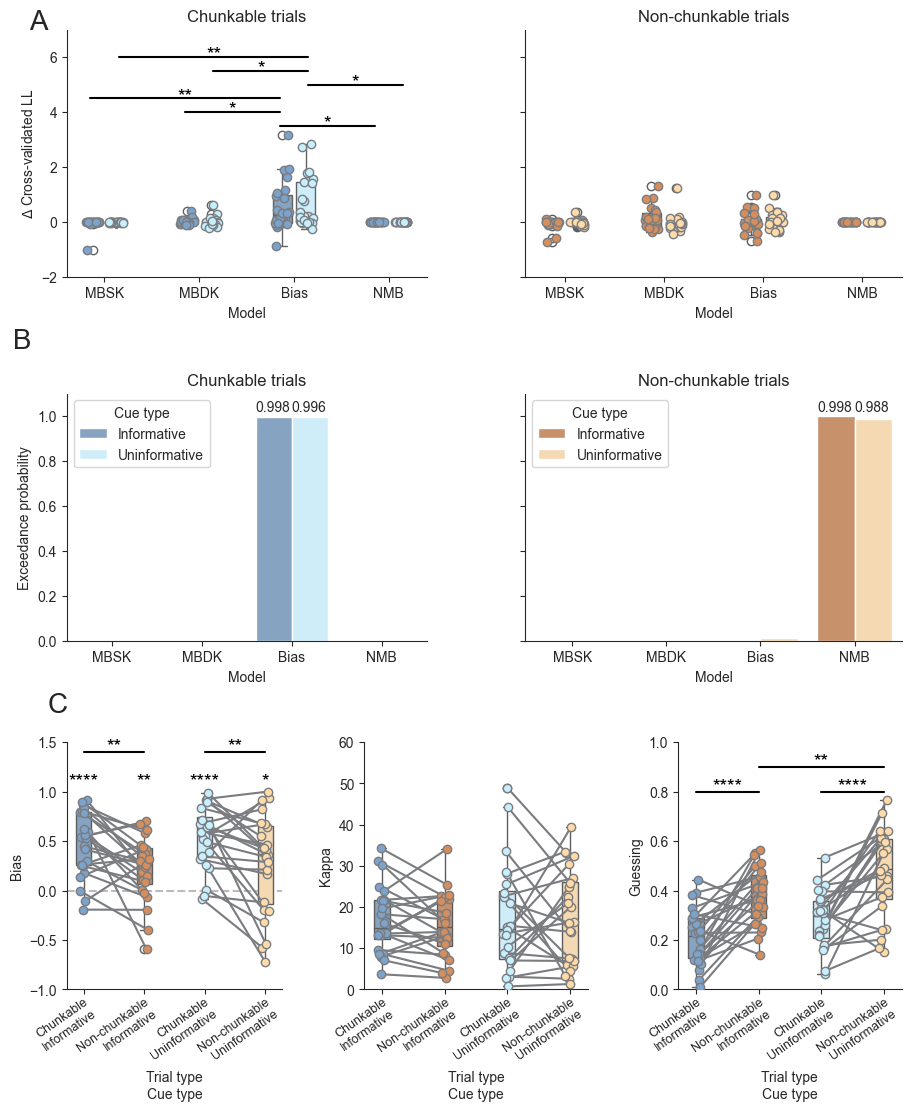

In [38]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A','A','B','B','B'],['C','C','C','D','D','D'],['E','E','F','F','G','G']],
                               figsize=(9,11),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0,0]: Model comparison (CV-LL) for chunking trials
modelCVLLDF = pandas.read_csv(exportsPath+'modelsTestLL.csv',index_col=0)
chunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_C_[I|U]').copy()
filterCU = chunkableTrialsDF.columns.str.contains(r"_C_U")
chunkableTrialsDF.loc[:,filterCU] = chunkableTrialsDF.loc[:,filterCU].sub(chunkableTrialsDF['NMB_C_U'],axis=0)
filterCI = chunkableTrialsDF.columns.str.contains(r"_C_I")
chunkableTrialsDF.loc[:,filterCI] = chunkableTrialsDF.loc[:,filterCI].sub(chunkableTrialsDF['NMB_C_I'],axis=0)
chunkableTrialsDF = chunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
chunkableTrialsDF['Cue type'] = chunkableTrialsDF.apply(lambda x: 'Informative' if x['Model'][-1]=='I' else 'Uninformative',axis=1)
chunkableTrialsDF['Model'] = chunkableTrialsDF['Model'].str.replace('_C_[I|U]','',regex=True)
seaborn.boxplot(ax=ax['A'],data=chunkableTrialsDF,x='Model',y='LL',hue='Cue type',gap=0.2,legend=False,
                width=0.5,palette={'Informative':'#7ca3cc','Uninformative':'#c7f0ff'})
varCounter = 0
for condition in chunkableTrialsDF['Model'].unique():
    dataPoints1 = chunkableTrialsDF[(chunkableTrialsDF['Model']==condition) & (chunkableTrialsDF['Cue type']=='Informative')]
    jitter1 = (numpy.random.uniform(low=-0.2,high=-0.05,size=(dataPoints1.shape[0],)))
    ax['A'].plot(varCounter+jitter1,dataPoints1['LL'],marker='o',
                 markerfacecolor='#7ca3cc',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    dataPoints2 = chunkableTrialsDF[(chunkableTrialsDF['Model']==condition) & (chunkableTrialsDF['Cue type']=='Uninformative')]
    jitter2 = (numpy.random.uniform(low=0.05,high=0.2,size=(dataPoints2.shape[0],)))
    ax['A'].plot(varCounter+jitter2,dataPoints2['LL'],marker='o',
                 markerfacecolor='#c7f0ff',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['A'].set_ylim(-2,7)
ax['A'].set_title("Chunkable trials")
ax['A'].set_ylabel(r"$\Delta$ Cross-validated LL")
pValue1 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-NMB']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([2,3])-0.15,3.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue1,texty=3.4)
pValue2 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-MBDK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([1,2])-0.15,4*numpy.array([1,1]),
                                               size=significanceSize,p=pValue2,texty=3.9)
pValue3 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-MBSK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([0,2])-0.15,4.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue3,texty=4.4)
pValue4 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-NMB']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([2,3])+0.15,5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue1,texty=4.9)
pValue5 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-MBDK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([1,2])+0.15,5.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue2,texty=5.4)
pValue6 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-MBSK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([0,2])+0.15,6*numpy.array([1,1]),
                                               size=significanceSize,p=pValue3,texty=5.9)
ax['A'].text(-0.8,7,'A',fontsize=20)

# Ax[0,1]: Model comparison (CV-LL) for chunking trials
nonChunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_NC_[I|U]').copy()
filterNCU = nonChunkableTrialsDF.columns.str.contains(r"_NC_U")
nonChunkableTrialsDF.loc[:,filterNCU] = nonChunkableTrialsDF.loc[:,filterNCU].sub(nonChunkableTrialsDF['NMB_NC_U'],axis=0)
filterNCI = nonChunkableTrialsDF.columns.str.contains(r"_NC_I")
nonChunkableTrialsDF.loc[:,filterNCI] = nonChunkableTrialsDF.loc[:,filterNCI].sub(nonChunkableTrialsDF['NMB_NC_I'],axis=0)
nonChunkableTrialsDF = nonChunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
nonChunkableTrialsDF['Cue type'] = nonChunkableTrialsDF.apply(lambda x: 'Informative' if x['Model'][-1]=='I' else 'Uninformative',axis=1)
nonChunkableTrialsDF['Model'] = nonChunkableTrialsDF['Model'].str.replace('_NC_[I|U]','',regex=True)
seaborn.boxplot(ax=ax['B'],data=nonChunkableTrialsDF,x='Model',y='LL',hue='Cue type',gap=0.2,legend=False,
                width=0.5,palette={'Informative':'#d68e5d','Uninformative':'#ffdba8'})
varCounter = 0
for condition in nonChunkableTrialsDF['Model'].unique():
    dataPoints1 = nonChunkableTrialsDF[(nonChunkableTrialsDF['Model']==condition) &
                                       (nonChunkableTrialsDF['Cue type']=='Informative')]
    jitter1 = (numpy.random.uniform(low=-0.2,high=-0.05,size=(dataPoints1.shape[0],)))
    ax['B'].plot(varCounter+jitter1,dataPoints1['LL'],marker='o',
                 markerfacecolor='#d68e5d',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    dataPoints2 = nonChunkableTrialsDF[(nonChunkableTrialsDF['Model']==condition) &
                                       (nonChunkableTrialsDF['Cue type']=='Uninformative')]
    jitter2 = (numpy.random.uniform(low=0.05,high=0.2,size=(dataPoints2.shape[0],)))
    ax['B'].plot(varCounter+jitter2,dataPoints2['LL'],marker='o',
                 markerfacecolor='#ffdba8',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['B'].set_ylim(-2,7)
ax['B'].set_title("Non-chunkable trials")
ax['B'].set_ylabel("")
ax['B'].set_yticklabels("")

# Ax[1,0]: Model comparison (SPM) for chunking trials
modelComparisonPlotData = {'Trial type':['Chunkable']*8+['Non-chunkable']*8,
                           'Model':['MBSK','MBDK','Bias','NMB']*4,
                           'Cue type':(['Informative']*4+['Uninformative']*4)*2,
                           'Exceedance probability':[modelComparisonData.loc[3,'xp_MBSK'],modelComparisonData.loc[3,'xp_MBDK'],
                                                     modelComparisonData.loc[3,'xp_Bias'],modelComparisonData.loc[3,'xp_NMB'],
                                                     modelComparisonData.loc[4,'xp_MBSK'],modelComparisonData.loc[4,'xp_MBDK'],
                                                     modelComparisonData.loc[4,'xp_Bias'],modelComparisonData.loc[4,'xp_NMB'],
                                                     modelComparisonData.loc[5,'xp_MBSK'],modelComparisonData.loc[5,'xp_MBDK'],
                                                     modelComparisonData.loc[5,'xp_Bias'],modelComparisonData.loc[5,'xp_NMB'],
                                                     modelComparisonData.loc[6,'xp_MBSK'],modelComparisonData.loc[6,'xp_MBDK'],
                                                     modelComparisonData.loc[6,'xp_Bias'],modelComparisonData.loc[6,'xp_NMB']]}
modelComaprisonPlotDF = pandas.DataFrame.from_dict(modelComparisonPlotData)
seaborn.barplot(ax=ax['C'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Chunkable',:],
                x='Model',y='Exceedance probability',hue='Cue type',palette=["#7ca3cc","#c7f0ff"])
ax['C'].set_ylim(0,1.1)
ax['C'].text(-1.1,1.3,'B',fontsize=20)
ax['C'].set_title("Chunkable trials")
ax['C'].text(1.6,1.02,f"{modelComparisonData.loc[3,'xp_Bias']:.3f}")
ax['C'].text(2,1.02,f"{modelComparisonData.loc[4,'xp_Bias']:.3f}")

# Ax[1,1]: Model comparison (SPM) for non-chunking trials
seaborn.barplot(ax=ax['D'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Non-chunkable',:],
                x='Model',y='Exceedance probability',hue='Cue type',palette=["#d68e5d","#ffdba8"])
ax['D'].set_ylim(0,1.1)
ax['D'].set_title("Non-chunkable trials")
ax['D'].set_ylabel("")
ax['D'].set_yticklabels("")
ax['D'].text(2.6,1.02,f"{modelComparisonData.loc[5,'xp_NMB']:.3f}")
ax['D'].text(3,1.02,f"{modelComparisonData.loc[6,'xp_NMB']:.3f}")

# Ax[2,0]: bias parameter
ax['E'].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
plottingDictionary = {'Subject':numpy.tile(numpy.unique(allParticipantData['Subject']),4),
                      'Trial type':numpy.tile(['Chunkable']*len(chunkingIParams['bias'])+['Non-chunkable']*len(chunkingIParams['bias']),2),
                      'Cue type':['Informative']*2*len(chunkingIParams['bias'])+['Uninformative']*2*len(chunkingIParams['bias']),
                      'Bias':chunkingIParams['bias']+nonChunkingIParams['bias']+chunkingUParams['bias']+nonChunkingUParams['bias'],
                      'Guessing':chunkingIParams['guessingP']+nonChunkingIParams['guessingP']+chunkingUParams['guessingP']+nonChunkingUParams['guessingP'],
                      'Kappa':chunkingIParams['kappa']+nonChunkingIParams['kappa']+chunkingUParams['kappa']+nonChunkingUParams['kappa']}
plottingDF = pandas.DataFrame.from_dict(plottingDictionary)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['E'],
                                            data=plottingDF,
                                            y='Bias',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['E'].set_xlim(-0.28,3.28)
ax['E'].set_ylim(-1,1.5)
jlib.display.utils.displayPairwiseSignificance(ax['E'],[0,1],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['E'],[2,3],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],0,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],1,1.05,size=significanceSize,
                                                p=2*biasICueFitsTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax['E'],2,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],3,1.05,size=significanceSize,
                                                p=2*biasUCueFitsTtestOS['ttest']['p'].to_numpy()[1])
ax['E'].text(-0.6,1.8,'C',fontsize=20)
for a in [ax['E']]:
    a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
    a.tick_params(axis='x', labelsize=9, pad=1)

# Ax[2,1]: kappa parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['F'],
                                            data=plottingDF,
                                            y='Kappa',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['F'].set_ylim(0,60)
for a in [ax['F']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

# Ax[2,2]: guessing parameter
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax['G'],
                                            data=plottingDF,
                                            y='Guessing',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax['G'].set_ylim(0,1)
jlib.display.utils.displayPairwiseSignificance(ax['G'],[1,3],0.9*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingNCTrialFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[0,1],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingICueFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax['G'],[2,3],0.8*numpy.array([1,1]),size=significanceSize,
                                               p=2*guessingUCueFitsTtestPS['ttest']['p'].to_numpy()[0])
for a in [ax['G']]:  # or iterate your axes
    a.set_xticklabels(a.get_xticklabels(),rotation=35,ha='right',rotation_mode='anchor')
    a.tick_params(axis='x',labelsize=9,pad=1)

seaborn.despine()

# if (saveFigs):
#     for format in imageFormats:
#         fig.savefig(imagePath+'biasModelsAndParams.'+format,format=format,dpi=1200)

C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1161133702.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['A'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1161133702.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['B'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1161133702.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['C'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
C:\Users\juanm\AppData\Local\Temp\ipykernel_66244\1161133702.py:116: UserWarning: set_ticklabels() should on

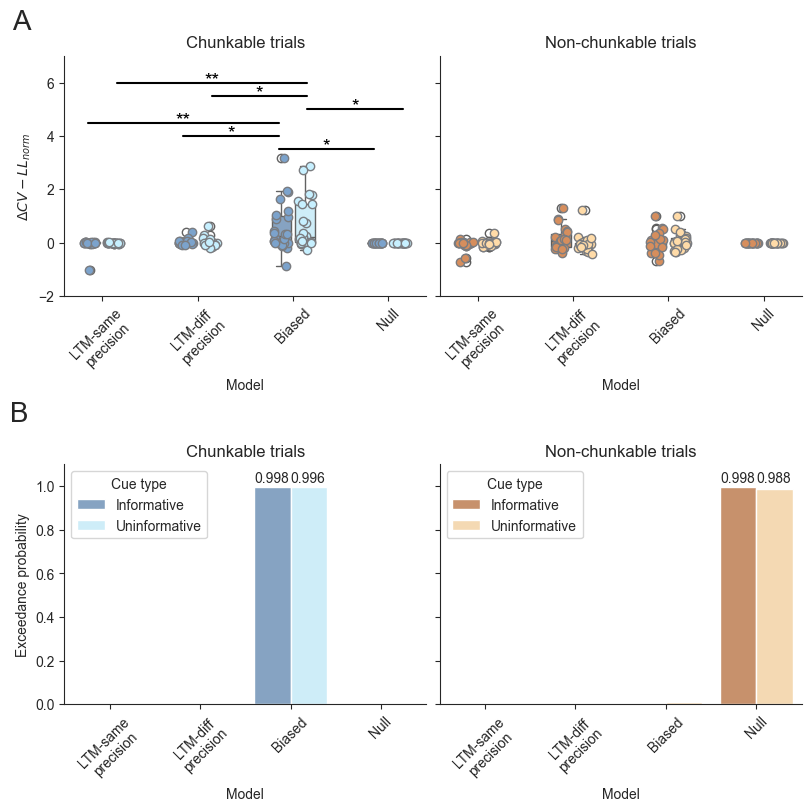

In [39]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A','A','B','B','B'],['C','C','C','D','D','D']],
                               figsize=(8,8),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0,0]: Model comparison (CV-LL) for chunking trials
modelCVLLDF = pandas.read_csv(exportsPath+'modelsTestLL.csv',index_col=0)
chunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_C_[I|U]').copy()
filterCU = chunkableTrialsDF.columns.str.contains(r"_C_U")
chunkableTrialsDF.loc[:,filterCU] = chunkableTrialsDF.loc[:,filterCU].sub(chunkableTrialsDF['NMB_C_U'],axis=0)
filterCI = chunkableTrialsDF.columns.str.contains(r"_C_I")
chunkableTrialsDF.loc[:,filterCI] = chunkableTrialsDF.loc[:,filterCI].sub(chunkableTrialsDF['NMB_C_I'],axis=0)
chunkableTrialsDF = chunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
chunkableTrialsDF['Cue type'] = chunkableTrialsDF.apply(lambda x: 'Informative' if x['Model'][-1]=='I' else 'Uninformative',axis=1)
chunkableTrialsDF['Model'] = chunkableTrialsDF['Model'].str.replace('_C_[I|U]','',regex=True)
seaborn.boxplot(ax=ax['A'],data=chunkableTrialsDF,x='Model',y='LL',hue='Cue type',gap=0.2,legend=False,
                width=0.5,palette={'Informative':'#7ca3cc','Uninformative':'#c7f0ff'})
varCounter = 0
for condition in chunkableTrialsDF['Model'].unique():
    dataPoints1 = chunkableTrialsDF[(chunkableTrialsDF['Model']==condition) & (chunkableTrialsDF['Cue type']=='Informative')]
    jitter1 = (numpy.random.uniform(low=-0.2,high=-0.05,size=(dataPoints1.shape[0],)))
    ax['A'].plot(varCounter+jitter1,dataPoints1['LL'],marker='o',
                 markerfacecolor='#7ca3cc',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    dataPoints2 = chunkableTrialsDF[(chunkableTrialsDF['Model']==condition) & (chunkableTrialsDF['Cue type']=='Uninformative')]
    jitter2 = (numpy.random.uniform(low=0.05,high=0.2,size=(dataPoints2.shape[0],)))
    ax['A'].plot(varCounter+jitter2,dataPoints2['LL'],marker='o',
                 markerfacecolor='#c7f0ff',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['A'].set_ylim(-2,7)
ax['A'].set_title("Chunkable trials")
ax['A'].set_ylabel(r"$\Delta CV-LL_{norm}$")
ax['A'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
pValue1 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-NMB']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([2,3])-0.15,3.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue1,texty=3.4)
pValue2 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-MBDK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([1,2])-0.15,4*numpy.array([1,1]),
                                               size=significanceSize,p=pValue2,texty=3.9)
pValue3 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialICueDiffBias-MBSK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([0,2])-0.15,4.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue3,texty=4.4)
pValue4 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-NMB']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([2,3])+0.15,5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue1,texty=4.9)
pValue5 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-MBDK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([1,2])+0.15,5.5*numpy.array([1,1]),
                                               size=significanceSize,p=pValue2,texty=5.4)
pValue6 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialUCueDiffBias-MBSK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],numpy.array([0,2])+0.15,6*numpy.array([1,1]),
                                               size=significanceSize,p=pValue3,texty=5.9)
ax['A'].text(-0.95,8,'A',fontsize=20)

# Ax[0,1]: Model comparison (CV-LL) for chunking trials
nonChunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_NC_[I|U]').copy()
filterNCU = nonChunkableTrialsDF.columns.str.contains(r"_NC_U")
nonChunkableTrialsDF.loc[:,filterNCU] = nonChunkableTrialsDF.loc[:,filterNCU].sub(nonChunkableTrialsDF['NMB_NC_U'],axis=0)
filterNCI = nonChunkableTrialsDF.columns.str.contains(r"_NC_I")
nonChunkableTrialsDF.loc[:,filterNCI] = nonChunkableTrialsDF.loc[:,filterNCI].sub(nonChunkableTrialsDF['NMB_NC_I'],axis=0)
nonChunkableTrialsDF = nonChunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
nonChunkableTrialsDF['Cue type'] = nonChunkableTrialsDF.apply(lambda x: 'Informative' if x['Model'][-1]=='I' else 'Uninformative',axis=1)
nonChunkableTrialsDF['Model'] = nonChunkableTrialsDF['Model'].str.replace('_NC_[I|U]','',regex=True)
seaborn.boxplot(ax=ax['B'],data=nonChunkableTrialsDF,x='Model',y='LL',hue='Cue type',gap=0.2,legend=False,
                width=0.5,palette={'Informative':'#d68e5d','Uninformative':'#ffdba8'})
varCounter = 0
for condition in nonChunkableTrialsDF['Model'].unique():
    dataPoints1 = nonChunkableTrialsDF[(nonChunkableTrialsDF['Model']==condition) &
                                       (nonChunkableTrialsDF['Cue type']=='Informative')]
    jitter1 = (numpy.random.uniform(low=-0.2,high=-0.05,size=(dataPoints1.shape[0],)))
    ax['B'].plot(varCounter+jitter1,dataPoints1['LL'],marker='o',
                 markerfacecolor='#d68e5d',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    dataPoints2 = nonChunkableTrialsDF[(nonChunkableTrialsDF['Model']==condition) &
                                       (nonChunkableTrialsDF['Cue type']=='Uninformative')]
    jitter2 = (numpy.random.uniform(low=0.05,high=0.2,size=(dataPoints2.shape[0],)))
    ax['B'].plot(varCounter+jitter2,dataPoints2['LL'],marker='o',
                 markerfacecolor='#ffdba8',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['B'].set_ylim(-2,7)
ax['B'].set_title("Non-chunkable trials")
ax['B'].set_ylabel("")
ax['B'].set_yticklabels("")
ax['B'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)

# Ax[1,0]: Model comparison (SPM) for chunking trials
modelComparisonPlotData = {'Trial type':['Chunkable']*8+['Non-chunkable']*8,
                           'Model':['MBSK','MBDK','Bias','NMB']*4,
                           'Cue type':(['Informative']*4+['Uninformative']*4)*2,
                           'Exceedance probability':[modelComparisonData.loc[3,'xp_MBSK'],modelComparisonData.loc[3,'xp_MBDK'],
                                                     modelComparisonData.loc[3,'xp_Bias'],modelComparisonData.loc[3,'xp_NMB'],
                                                     modelComparisonData.loc[4,'xp_MBSK'],modelComparisonData.loc[4,'xp_MBDK'],
                                                     modelComparisonData.loc[4,'xp_Bias'],modelComparisonData.loc[4,'xp_NMB'],
                                                     modelComparisonData.loc[5,'xp_MBSK'],modelComparisonData.loc[5,'xp_MBDK'],
                                                     modelComparisonData.loc[5,'xp_Bias'],modelComparisonData.loc[5,'xp_NMB'],
                                                     modelComparisonData.loc[6,'xp_MBSK'],modelComparisonData.loc[6,'xp_MBDK'],
                                                     modelComparisonData.loc[6,'xp_Bias'],modelComparisonData.loc[6,'xp_NMB']]}
modelComaprisonPlotDF = pandas.DataFrame.from_dict(modelComparisonPlotData)
seaborn.barplot(ax=ax['C'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Chunkable',:],
                x='Model',y='Exceedance probability',hue='Cue type',palette=["#7ca3cc","#c7f0ff"])
ax['C'].set_ylim(0,1.1)
ax['C'].text(-1.1,1.3,'B',fontsize=20)
ax['C'].set_title("Chunkable trials")
ax['C'].text(1.6,1.02,f"{modelComparisonData.loc[3,'xp_Bias']:.3f}")
ax['C'].text(2,1.02,f"{modelComparisonData.loc[4,'xp_Bias']:.3f}")
ax['C'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)

# Ax[1,1]: Model comparison (SPM) for non-chunking trials
seaborn.barplot(ax=ax['D'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Non-chunkable',:],
                x='Model',y='Exceedance probability',hue='Cue type',palette=["#d68e5d","#ffdba8"])
ax['D'].set_ylim(0,1.1)
ax['D'].set_title("Non-chunkable trials")
ax['D'].set_ylabel("")
ax['D'].set_yticklabels("")
ax['D'].text(2.6,1.02,f"{modelComparisonData.loc[5,'xp_NMB']:.3f}")
ax['D'].text(3,1.02,f"{modelComparisonData.loc[6,'xp_NMB']:.3f}")
ax['D'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'exp4ModelsSupplementary.'+format,format=format,dpi=1200)